# 04_compare.ipynb — LSTM vs PatchTST 比較

このノートブックでやること:
- test データで MAE / RMSE を評価
- LSTM（第3弾）と PatchTST の結果を比較
- ステップ別誤差（翌1日〜7日）の比較
- 予測グラフの可視化

In [ ]:
!pip install -q "transformers>=4.41.0"

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from pathlib import Path
import numpy as np
import pickle
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import PatchTSTConfig, PatchTSTForPrediction
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

DATA_LSTM_PROC = Path('/content/drive/MyDrive/project/weather-lstm/processed')
DATA_PROC      = Path('/content/drive/MyDrive/project/weather-patchtst/processed')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'デバイス: {device}')

SEQ_LEN_LSTM   = 30
SEQ_LEN_PATCH  = 60
PRED_LEN       = 7
BATCH_SIZE     = 32

デバイス: cuda


## 1. PatchTST でテストデータを推論

In [4]:
# データ読み込み（03_train で保存した seq_len=60 版）
X_test = np.load(DATA_PROC / 'X_test.npy')
y_test = np.load(DATA_PROC / 'y_test.npy')
with open(DATA_PROC / 'scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

class WeatherDatasetPatchTST(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

test_loader = DataLoader(WeatherDatasetPatchTST(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)
print(f'test: {len(X_test)} samples')

test: 539 samples


In [5]:
# モデル復元（03_train と同じ config）
config = PatchTSTConfig(
    num_input_channels=1,
    context_length=SEQ_LEN_PATCH,
    prediction_length=PRED_LEN,
    patch_length=6, stride=2,
    d_model=64, num_attention_heads=4, num_hidden_layers=2,
    ffn_dim=128, dropout=0.3, head_dropout=0.3,
    pooling_type='mean',
)
model = PatchTSTForPrediction(config).to(device)
model.load_state_dict(torch.load(DATA_PROC / 'best_model.pth', map_location=device))
model.eval()
print('モデル読み込み完了')

モデル読み込み完了


In [6]:
# 推論
preds_scaled, trues_scaled = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        output = model(past_values=X_batch.to(device))
        preds_scaled.append(output.prediction_outputs.squeeze(-1).cpu().numpy())
        trues_scaled.append(y_batch.squeeze(-1).numpy())

preds_scaled = np.concatenate(preds_scaled)  # (N, 7)
trues_scaled = np.concatenate(trues_scaled)

# 逆変換（℃に戻す）
preds = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).reshape(preds_scaled.shape)
trues = scaler.inverse_transform(trues_scaled.reshape(-1, 1)).reshape(trues_scaled.shape)

print(f'推論完了: preds={preds.shape}, trues={trues.shape}')

推論完了: preds=(539, 7), trues=(539, 7)


## 2. MAE / RMSE 計算

In [7]:
mae  = np.mean(np.abs(preds - trues))
rmse = np.sqrt(np.mean((preds - trues) ** 2))

# 第3弾 LSTM の結果（固定値）
LSTM_MAE  = 2.12
LSTM_RMSE = 2.72

print('=' * 40)
print(f'         MAE (℃)   RMSE (℃)')
print(f'LSTM     {LSTM_MAE:.2f}       {LSTM_RMSE:.2f}')
print(f'PatchTST {mae:.2f}       {rmse:.2f}')
print('=' * 40)

mae_diff = LSTM_MAE - mae
if mae_diff > 0:
    print(f'→ MAE が {mae_diff:.2f}℃ 改善 ✅')
else:
    print(f'→ LSTM の方が MAE {-mae_diff:.2f}℃ 優勢')

         MAE (℃)   RMSE (℃)
LSTM     2.12       2.72
PatchTST 2.04       2.64
→ MAE が 0.08℃ 改善 ✅


## 3. ステップ別 MAE（翌1日〜7日）

In [8]:
# 第3弾のステップ別MAE（記事から）
lstm_step_mae = {1: 1.59, 3: 2.12, 7: 2.37}

patch_step_mae = [np.mean(np.abs(preds[:, i] - trues[:, i])) for i in range(PRED_LEN)]

print(f'{'ステップ':>8}  {'LSTM MAE':>10}  {'PatchTST MAE':>12}  {'差分':>8}')
print('-' * 48)
for i in range(PRED_LEN):
    step = i + 1
    lstm_val = lstm_step_mae.get(step, None)
    p_val    = patch_step_mae[i]
    if lstm_val:
        diff = lstm_val - p_val
        mark = '✅' if diff > 0 else ''
        print(f'翌{step}日目  {lstm_val:>10.2f}  {p_val:>12.2f}  {diff:>+8.2f} {mark}')
    else:
        print(f'翌{step}日目  {'—':>10}  {p_val:>12.2f}')

    ステップ    LSTM MAE  PatchTST MAE        差分
------------------------------------------------
翌1日目        1.59          1.73     -0.14 
翌2日目           —          1.89
翌3日目        2.12          2.01     +0.11 ✅
翌4日目           —          2.08
翌5日目           —          2.13
翌6日目           —          2.20
翌7日目        2.37          2.25     +0.12 ✅


In [12]:
!pip install -q japanize-matplotlib

/tmp/ipykernel_10025/3528486610.py:16: UserWarning: Glyph 20104 (\N{CJK UNIFIED IDEOGRAPH-4E88}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10025/3528486610.py:16: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10025/3528486610.py:16: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10025/3528486610.py:16: UserWarning: Glyph 12486 (\N{KATAKANA LETTER TE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10025/3528486610.py:16: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10025/3528486610.py:16: UserWarning: Glyph 12503 (\N{KATAKANA LETTER PU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10025/3528486610.py:16: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font

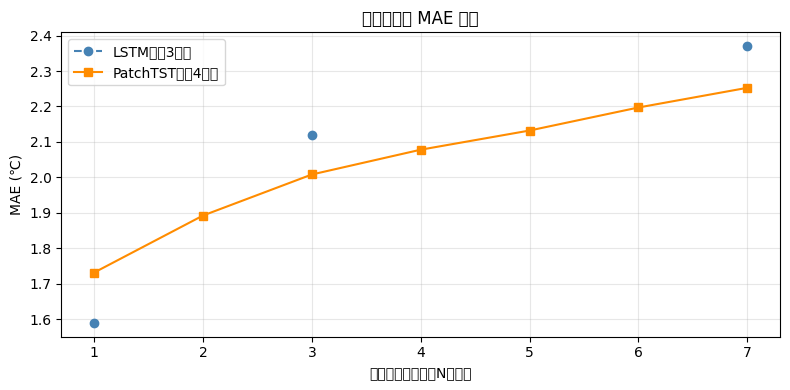

In [13]:
i

# ステップ別MAE グラフ
steps = list(range(1, PRED_LEN + 1))
lstm_vals  = [lstm_step_mae.get(s, np.nan) for s in steps]

plt.figure(figsize=(8, 4))
plt.plot(steps, lstm_vals,     'o--', color='steelblue',  label='LSTM（第3弾）', linewidth=1.5)
plt.plot(steps, patch_step_mae, 's-',  color='darkorange', label='PatchTST（第4弾）', linewidth=1.5)
plt.xlabel('予測ステップ（翌N日目）')
plt.ylabel('MAE (℃)')
plt.title('ステップ別 MAE 比較')
plt.xticks(steps)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(DATA_PROC / 'step_mae_comparison.png', dpi=150)
plt.show()

## 4. 予測グラフ（test期間の一部）

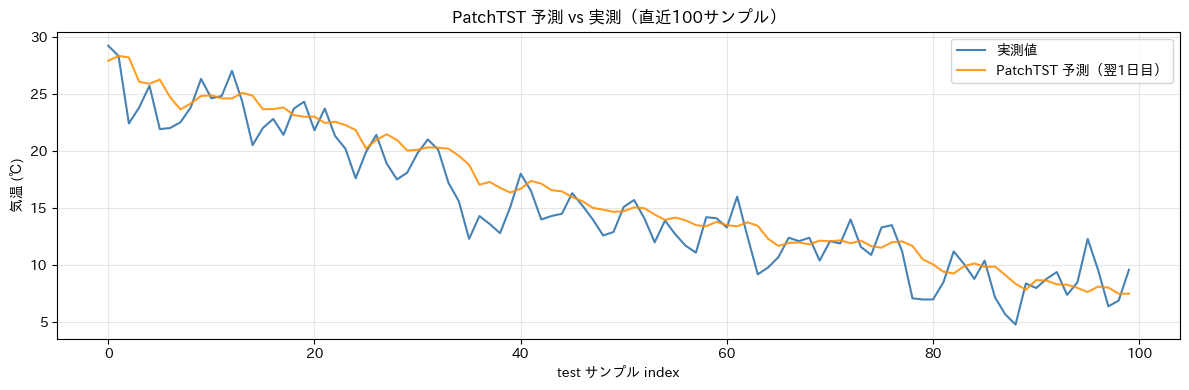

In [17]:
import japanize_matplotlib
# 翌1日目予測を時系列で可視化（直近100日分）
n_show = 100
actual = trues[-n_show:, 0]
pred1  = preds[-n_show:, 0]

plt.figure(figsize=(12, 4))
plt.plot(actual, label='実測値', color='steelblue', linewidth=1.5)
plt.plot(pred1,  label='PatchTST 予測（翌1日目）', color='darkorange', linewidth=1.5, alpha=0.85)
plt.xlabel('test サンプル index')
plt.ylabel('気温 (℃)')
plt.title('PatchTST 予測 vs 実測（直近100サンプル）')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(DATA_PROC / 'prediction_plot.png', dpi=150)
plt.show()

## 5. 最終サマリー

In [11]:
print('=' * 50)
print('  第3弾 vs 第4弾 最終比較')
print('=' * 50)
print(f'  モデル    : LSTM 2層           vs  PatchTST')
print(f'  seq_len   : 30日               vs  60日')
print(f'  パラメータ: ~50k               vs  {sum(p.numel() for p in model.parameters()):,}')
print(f'  MAE       : {LSTM_MAE:.2f} ℃           vs  {mae:.2f} ℃')
print(f'  RMSE      : {LSTM_RMSE:.2f} ℃           vs  {rmse:.2f} ℃')
print('=' * 50)

# 結果保存
import json
results = {
    'lstm':     {'mae': LSTM_MAE, 'rmse': LSTM_RMSE, 'seq_len': SEQ_LEN_LSTM},
    'patchtst': {'mae': float(round(mae, 2)), 'rmse': float(round(rmse, 2)), 'seq_len': SEQ_LEN_PATCH},
}
with open(DATA_PROC / 'results.json', 'w') as f:
    json.dump(results, f, indent=2)
print('結果を results.json に保存しました')

  第3弾 vs 第4弾 最終比較
  モデル    : LSTM 2層           vs  PatchTST
  seq_len   : 30日               vs  60日
  パラメータ: ~50k               vs  71,367
  MAE       : 2.12 ℃           vs  2.04 ℃
  RMSE      : 2.72 ℃           vs  2.64 ℃
結果を results.json に保存しました
